# Project 1: Differentiaalvergelijkingen

## 1. Wat is een differentiaalvergelijking?

Een **gewone vergelijking** kennen we allemaal: dit is een gelijkheid met één of meer onbekenden ($x$, $y$, ...) waarvan de oplossing bestaat uit een getalwaarde voor elke onbekende, zodat aan de gelijkheid voldaan is.
$$
5x + 2 = -2y + 1, \qquad x^2 - 3x + 2 = 0, \qquad \dots
$$
Je leerde ondertussen 'oplossingstechnieken' gebruiken voor verschillende types vergelijkingen. Voor een tweedegraadsvergelijking kan je bijvoorbeeld de discriminantformule gebruiken.

Een andere soort vergelijkingen zijn **functievergelijkingen**. Hierbij wordt er niet gezocht naar een getalwaarde, maar naar een functie die aan de gelijkheid voldoet. We geven enkele voorbeelden.
$$ f(x) = f(-x) $$
* De bovenstaande vergelijking impliceert dat $f(1) = f(-1)$, $f(2) = f(-2)$ enzovoort. Dit is precies de definitie van een even functie. Elke even functie voldoet dus aan deze vergelijking.
$$ f(x + 2\pi) = f(x) $$
* Deze vergelijking drukt uit dat de functie $g$ periodiek is met periode $2\pi$. Oplossingen hiervoor zijn de goniometrische functies.
$$ f'(x) + \frac{f(x)}{x} = 3x $$
* In deze vergelijking komt niet enkel de functie $f$ voor, maar ook haar afgeleide. Dat de algemene oplossing hier de vorm
$$ f(x) = x^2 + \frac{a - 1}{x} $$
heeft, ligt hier minder voor de hand.

Wanneer een vergelijking gaat over een functie en één of meer van haar afgeleiden, spreken van een **differentiaalvergelijking**. In dit project leren we hoe je eenvoudige differentiaalvergelijkingen numeriek oplost met behulp van Python.

## 2. Discretisatie

### 2.1. Discretisatie van een functie

Vóór we verder onderzoeken hoe we differentiaalvergelijkingen kunnen oplossen — gebruikmakend van de computer — is het belangrijk om te wijzen op het discrete karakter van computers. We nemen hieronder als voorbeeld de tweedegraadsfunctie
$$
\boxed{f(x)=x^2-3x+1}.
$$

Binnen de wiskunde is de grafiek van de functie $f(x)=x^2-3x+1$ een continue, vloeiende kromme. Voor élke x-waarde bestaat er een unieke y-waarde. Bij de x-waarde 3.14 hoort bijvoorbeeld de y-waarde 1.4396. Computers kunnen echter maar een eindig of discreet aantal punten tekenen, waar je — soms met enige verbeelding — een doorlopende kromme in kan zien. 

<img src='https://raw.githubusercontent.com/jvercruysse/IW_Teams/main/media/P6_project1_discretisatie.png' width='50%'>

De grafiek die wordt getekend door onze computer is duidelijk geen continue kromme, maar een opeenvolging van discrete punten waarin je — met enige verbeelding — een parabool kan zien. In de x-waarde 3.14 kunnen we op de grafiek geen functiewaarde aflezen, we kunnen enkel een schatting maken door het punt te beschouwen dat het dichtst in de buurt komt. De reden dat de computer geen vloeiende lijn toont, is uiteraard omdat deze in theorie bestaat uit een oneindig aantal punten. Om al deze punten te tekenen, zou een computer dan ook oneindig lang bezig zijn. Een computer werkt dus **altijd** discreet, door zich te beperken zich tot een eindig aantal punten.

Voor een programmeur heeft **discretisatie** verschillende gevolgen, waarvan er één telkens terugkomt. Een programmeur is gedoemd om altijd de afweging te maken tussen:

- het tekenen van voldoende punten om detail te bekomen;
- en het tekenen van te veel punten, wat leidt tot lange wachttijden. 

We geven een voorbeeld van een reëel gevolg van deze afweging. Een weersvoorspellingsmodel simuleert het weer in supercomputers, door de volledige atmosfeer van de aarde in miljarden kubusjes te verdelen. Op elk van de hoekpunten van die kubusjes worden berekeningen uitgevoerd, om de zogenaamde [Navier-Stokes-vergelijkingen](https://en.wikipedia.org/wiki/Navier%E2%80%93Stokes_equations) waaraan de luchtstromen voldoen, op te lossen. In totaal worden via die complexe berekeningen temperatuur, druk, wind en vele andere meteorologische variabelen voorspeld, stapje voor stapje vooruit in de tijd. Ook al gebeuren die berekeningen door supercomputers, dan nog moet de weerman of -vrouw ten allen tijde vermijden dat de berekeningen té lang duren. Niemand wil immers 24 uur wachten op een voorspelling voor deze namiddag. Lange wachttijden kunnen we perfect vermijden door minder kubusjes te kiezen, maar minder kubusjes leiden weer tot een minder nauwkeurige voorspelling ...

### 2.2. Discretisatie van de afgeleide functie

Neem opnieuw de bovenstaande functie met als voorschrift $f(x)=x^2-3x+1$ en neem aan dat we hiervan de afgeleide in $x=1$ willen bepalen. We noteren dit met $\frac{df(1)}{dx}$, wat identiek is aan $Df(1)$ of $f'(1)$. Aan de hand van rekenregels kan je de afgeleide van deze simpele veeltermfunctie uiteraarde snel berekenen:
$$
\frac{df(x)}{dx} = \frac{d}{dx}(x^2-3x+1) = 2x - 3 \qquad\Rightarrow\qquad \frac{df(1)}{dx} = -1.
$$

Wanneer de gekende rekenregels falen, moeten we terugvallen op de limietdefinitie voor de afgeleide in een punt:
$$
\boxed{\frac{df(a)}{dx} = \lim_{\Delta x \to 0} \frac{f(a + \Delta x) - f(a)}{\Delta x}}.
$$
In woorden uitgedrukt: bereken het differentiequotiënt in het interval $[a, a + \Delta x]$ en laat vervolgens de **stapgrootte** naar nul naderen via een limiet. De teller van deze breuk wordt ook wel een **voorwaartse differentie** van $f$ genoemd, met stapgrootte $h$.

Voor heel wat functies zijn rekenregels voor afgeleiden te complex, waardoor je bent toegewezen op de limietdefinitie. Je kan deze limietdefinitie discretiseren, zodat de computer (benaderend) afgeleiden kan berekenen. Er is echter één probleem: in paragraaf 2.1 hebben we gezien dat een computer de waarde $\Delta x$ niet willekeurig dicht laten naderen tot $0$ om de afgeleide $\frac{df(a)}{dx}$ te berekenen: de computer werkt namelijk discreet. Bijgevolg zal je in berekeningen zelf de keuze moeten maken welke waarde voor $\Delta x$ je gebruikt. Klein genoeg, zodat de limiet zoals je deze zou berekenen op papier, hier ongeveer aan gelijk is.
$$
\boxed{\frac{df(a)}{dx} \approx \frac{\Delta f(a)}{\Delta x} = \frac{f(a+\Delta x) - f(a)}{\Delta x}}
$$
In veel probleemsituaties worden afgeleiden benaderd met behulp van differenties. Men spreekt dan van een **eindige differentiemethode** voor het probleem.

## 3. De methode van Euler

Nu we een methode hebben gevonden om afgeleiden van eender welke functie te benaderen, herleggen we de focus naar het oplossen van een differentiaalvergelijking. Om met een computer een gewone vergelijking met onbekende $x$ op te lossen, begin je meestal met een gok voor $x$, die je via berekeningen vervolgens bijstelt. In een vergelijking met een onbekende functie $f(x)$ lijkt het onbegonnen werk om de computer voorschriften te laten uitproberen: hoe zou je alle mogelijke voorschriften met $x$, $x^2$, $\sin x$ ... uitproberen?

Daarom verleggen we onze focus: van het zoeken naar een voorschrift, naar het tekenen van de grafiek. Om de grafiek van $f$ te tekenen, moet de computer door het principe van discretisatie namelijk slechts een eindig aantal punten berekenen. Hiervoor zullen we de methode van Euler gebruiken, die werd gebruikt door Leonhard Euler (1707-1783) om de banen van planeten te bestuderen. Deze kan gebruikt worden om _lineaire differentiaalvergelijkingen van de eerste orde_ op te lossen. Als we de onbekende functie noteren als $y(x)$, ziet zo'n vergelijking er steeds als volgt uit:
$$
y' = f(x,y),
$$
waarbij $f$ een functie voorstelt van $x$ en $y$ die lineair is in $y$. De differentiaalvergelijking
$$
y' = 5y + \sin x
$$
is bijvoorbeeld lineair met $f(x,y) = 5y + \sin x$, aangezien er geen termen optreden zoals $y^2$ of $\sin y$.

### 3.1. Tekenen van een discrete oplossing

Om tot de methode van Euler te komen, herinneren we nog eens aan de meetkundige betekenis van afgeleiden. De afgeleide $f'(a)$ in een punt $P\big(a, f(a)\big)$ geeft de richting (rico) van de raaklijn weer. Bovendien is de raaklijn in $P$ steeds een goede benadering van de grafiek van $f$ in de omgeving van dit punt. We kunnen dus van een gegeven startpunt één stap opzij zetten langs de raaklijn, via de formule

$$\frac{df(a)}{dx} \approx \frac{f(a+\Delta x) - f(a)}{\Delta x} \qquad\Longleftrightarrow\qquad \boxed{f(a+\Delta x) \approx f(a) + \Delta x \cdot \frac{df(a)}{dx}}$$

Hoe kleiner de stapgrootte $\Delta x$, hoe dichter de uitdrukking in het rechterlid zal liggen bij de functiewaarde in het nieuwe punt $Q$. Dit wordt de **methode van Euler** genoemd en het is de eenvoudigste manier om een differentiaalvergelijking numeriek op te lossen.

<img src='https://raw.githubusercontent.com/jvercruysse/IW_Teams/main/media/P6_project1_raaklijn.png' width='50%'>


### 3.2. Uitgewerkt voorbeeld: bevolkingsgroei

Volgens de projecties van [_Worldometer_](https://www.worldometers.info/world-population/world-population-projections/) bedraagt de huidige wereldbevolking ongeveer 8,23 miljard mensen en wordt de gemiddelde groei voor de komende vijf jaren geschat op 0.81\%. Aks we het huidige bevolkingsaantal noteren met $N(0) = N_0$ en de bevolkingsgroei per jaar met $k$, dan kunnen we de populatiegroei beschrijven met behulp van de volgende differentiaalvergelijking:
$$
\frac{dN(t)}{dt} = k \cdot N(t)
$$
met $N(t)$ de gezochte functie die de populatie beschrijft in functie van de tijd.

We bepalen een numerieke oplossing met behulp van de methode van Euler. Hiervoor gaan we als volgt te werk.

Eerst maken we een lijst van waarden $[t_0, t_1, t_2 ...]$, waarin we verder in de code de benaderingen $[N_0, N_1, N_2 ...]$ zullen berekenen. Hiervoor is het commando `np.arange(start, eind, stapgrootte)` zeer geschikt.

In [6]:
import numpy as np

#==================================#
#====    AANMAAK VARIABELEN    ====#
#==================================#

N0        = 8_230_000_000          # wereldbevolking
k         = 0.0081                 # gemiddelde bevolkingsgroei per jaar
dt        = 1                      # tijdsstap in jaar, verklein deze waarde voor een nauwkeurigere oplossing
tijdlijst = np.arange(0,10,dt)     # lijst van 0 tot 10 jaar in stappen van delta t jaar

De methode van Euler levert ons de formule om de volgende waarde $N_1$ te berekenen:
$$
N(t_1) \approx N_1 = N_0 + k N_0 \cdot \Delta t
$$

Eens $N_1$ berekend is, kunnen we de volgende tijdstap $N_2$ berekenen, daarna $N_3$ enzovoort. Zo doen we verder tot we de gewenste eindtijd hebben bereikt. Dit is hieronder in een for-loop geïmplementeerd. Let op het gebruik van $N_0$ en $N_1$ als enige variabelenamen: $N_2$, $N_3$... worden nooit aangemaakt om geheugen uit te sparen!

In [4]:
import numpy as np

#==================================#
#====    AANMAAK VARIABELEN    ====#
#==================================#

N0        = 8.23                   # wereldbevolking
k         = 0.0081                 # gemiddelde bevolkingsgroei per jaar
dt        = 1                      # tijdsstap in jaar, verklein deze waarde voor een nauwkeurigere oplossing
tijdlijst = np.arange(0,11,dt)     # lijst van 0 tot 10 jaar in stappen van delta t jaar

#===================================#
#===  IMPLEMENTATIE DISCRETE DV  ===#
#===================================#

for t in tijdlijst:
    N1 = N0 + k*N0 * dt
    N0 = N1

#===================================#
#=== PRINT POPULATIE OP 'T EINDE ===#
#===================================#

print( 'Na', tijdlijst[-1], 'jaar telt de wereld ongeveer', round(N0,2), 'miljard mensen.' )

Na 10 jaar telt de wereld ongeveer 8.99 miljard mensen.


Indien we de grafiek willen tekenen, moeten we de berekende waarden bijhouden in een lijst `populatie`. We passen de for-loop aan, zodat `N0` telkens wordt toegevoegd aan de lijst.

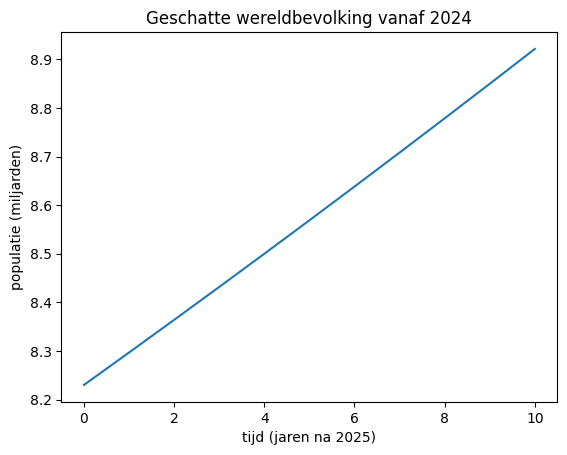

Na 10 jaar telt de wereld ongeveer 8.99 miljard mensen.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

#==================================#
#====    AANMAAK VARIABELEN    ====#
#==================================#

N0        = 8.23                   # wereldbevolking
k         = 0.0081                 # gemiddelde bevolkingsgroei per jaar
dt        = 1                      # tijdsstap in jaar, verklein deze waarde voor een nauwkeurigere oplossing
tijdlijst = np.arange(0,11+dt,dt)     # lijst van 0 tot 10 jaar in stappen van delta t jaar
populatie = []                     # voorlopig lege lijst met de geschatte populatieaantallen voor elke tijdstap

#===================================#
#===  IMPLEMENTATIE DISCRETE DV  ===#
#===================================#

for t in tijdlijst:
    populatie.append( N0 )          # voeg nieuwe populatie toe
    N1 = N0 + k*N0*dt               # bereken populatie voor de volgende tijdsstap
    N0 = N1                         #

#===================================#
#=== AANMAAK VAN DE N(t) GRAFIEK ===#
#===================================#

fig, ax = plt.subplots()
ax.plot(tijdlijst, populatie)
ax.set_title('Geschatte wereldbevolking vanaf 2024')
ax.set_xlabel( 'tijd (jaren na 2025)' )
ax.set_ylabel( 'populatie (miljarden)' )
plt.show()

print( 'Na', tijdlijst[-1], 'jaar telt de wereld ongeveer', round(N0, 2), 'miljard mensen.' )